<a href="https://colab.research.google.com/github/JoelDrake302/ML-AutoTheft/blob/Unsupervised-Model/auto_theft_risk_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 Auto Theft Risk Clustering — Unsupervised Learning Pipeline

**Objective:** Classify auto theft incidents into **High Risk** and **Low Risk** categories using KMeans clustering, then validate cluster quality with a Random Forest classifier.

**Pipeline Overview:**
1. Data Loading & Exploration
2. Feature Engineering (composite risk scoring, cyclical encodings)
3. KMeans Clustering with Elbow & Silhouette selection
4. Cluster Profiling & Labelling
5. Classifier Validation (75/25 split, 5-fold CV)
6. Evaluation (Accuracy, ROC-AUC, F1, Confusion Matrix)
7. Visualisation Dashboard

---

## 1. 📦 Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    accuracy_score, roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Plot style
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 9
})

BLUE  = '#2563EB'
RED   = '#DC2626'
AMBER = '#F59E0B'
GREEN = '#16A34A'
GRAY  = '#6B7280'

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. 📂 Data Loading & Exploration

In [4]:
import gdown

# Google Drive file ID
file_id = '190IgZ2OhktJOw7K7Fws_yMkWzQVznmOp'
output = 'Auto_Theft_Open_Data_3636037395679683176.csv'

gdown.download(id=file_id, output=output, quiet=False)

DATA_PATH = output

df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Downloading...
From: https://drive.google.com/uc?id=190IgZ2OhktJOw7K7Fws_yMkWzQVznmOp
To: /content/Auto_Theft_Open_Data_3636037395679683176.csv
100%|██████████| 25.7M/25.7M [00:00<00:00, 51.0MB/s]


Dataset shape: (76749, 32)
Columns: ['OBJECTID', 'EVENT_UNIQUE_ID', 'REPORT_DATE', 'OCC_DATE', 'REPORT_YEAR', 'REPORT_MONTH', 'REPORT_DAY', 'REPORT_DOY', 'REPORT_DOW', 'REPORT_HOUR', 'OCC_YEAR', 'OCC_MONTH', 'OCC_DAY', 'OCC_DOY', 'OCC_DOW', 'OCC_HOUR', 'DIVISION', 'LOCATION_TYPE', 'PREMISES_TYPE', 'UCR_CODE', 'UCR_EXT', 'OFFENCE', 'CSI_CATEGORY', 'HOOD_158', 'NEIGHBOURHOOD_158', 'Region', 'HOOD_140', 'NEIGHBOURHOOD_140', 'LONG_WGS84', 'LAT_WGS84', 'x', 'y']


In [5]:
df.head()

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,CSI_CATEGORY,HOOD_158,NEIGHBOURHOOD_158,Region,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y
0,1,GO-20141262837,01/01/14 5:00,12/25/2013 5:00:00 AM,2014,January,1,1,Wednesday,15,...,Auto Theft,159,Etobicoke City Centre (159),Region. 1,14,Islington-City Centre West (14),-79.529692,43.618988,-8853204.784,5406667.722
1,2,GO-20141263217,01/01/14 5:00,12/31/2013 5:00:00 AM,2014,January,1,1,Wednesday,16,...,Auto Theft,43,Victoria Village (43),NaN,43,Victoria Village (43),-79.306754,43.734654,-8828387.423,5424470.688
2,3,GO-20141262914,01/01/14 5:00,01/01/14 5:00,2014,January,1,1,Wednesday,15,...,Auto Theft,123,Cliffcrest (123),NaN,123,Cliffcrest (123),-79.236119,43.721827,-8820524.401,5422494.748
3,4,GO-20141266240,01/02/14 5:00,01/02/14 5:00,2014,January,2,2,Thursday,9,...,Auto Theft,60,Woodbine-Lumsden (60),NaN,60,Woodbine-Lumsden (60),-79.313796,43.688101,-8829171.433,5417301.224
4,5,GO-20141266097,01/02/14 5:00,01/02/14 5:00,2014,January,2,2,Thursday,8,...,Auto Theft,129,Agincourt North (129),NaN,129,Agincourt North (129),-79.273925,43.813557,-8824733.012,5436634.962


In [6]:
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum()[df.isnull().sum() > 0])

--- Data Types ---
OBJECTID               int64
EVENT_UNIQUE_ID       object
REPORT_DATE           object
OCC_DATE              object
REPORT_YEAR            int64
REPORT_MONTH          object
REPORT_DAY             int64
REPORT_DOY             int64
REPORT_DOW            object
REPORT_HOUR            int64
OCC_YEAR             float64
OCC_MONTH             object
OCC_DAY              float64
OCC_DOY              float64
OCC_DOW               object
OCC_HOUR               int64
DIVISION              object
LOCATION_TYPE         object
PREMISES_TYPE         object
UCR_CODE               int64
UCR_EXT                int64
OFFENCE               object
CSI_CATEGORY          object
HOOD_158              object
NEIGHBOURHOOD_158     object
Region                object
HOOD_140              object
NEIGHBOURHOOD_140     object
LONG_WGS84           float64
LAT_WGS84            float64
x                    float64
y                    float64
dtype: object

--- Missing Values ---
OCC_YEAR       

In [7]:
print('PREMISES_TYPE:\n', df['PREMISES_TYPE'].value_counts())
print('\nLOCATION_TYPE (top 5):\n', df['LOCATION_TYPE'].value_counts().head())
print('\nDIVISION:\n', df['DIVISION'].value_counts())
print('\nOCC_YEAR range:\n', df['OCC_YEAR'].value_counts().sort_index().tail(10))

PREMISES_TYPE:
 PREMISES_TYPE
Outside        41847
House          23352
Commercial      6381
Apartment       2500
Other           2322
Transit          251
Educational       96
Name: count, dtype: int64

LOCATION_TYPE (top 5):
 LOCATION_TYPE
Parking Lots (Apt., Commercial Or Non-Commercial)                         27502
Single Home, House (Attach Garage, Cottage, Mobile)                       23352
Streets, Roads, Highways (Bicycle Path, Private Road)                     14149
Other Commercial / Corporate Places (For Profit, Warehouse, Corp. Bldg     3907
Apartment (Rooming House, Condo)                                           2500
Name: count, dtype: int64

DIVISION:
 DIVISION
D23    10347
D32     8700
D31     7390
D22     7359
D42     6383
D41     4675
D43     4596
D33     4414
D53     4099
D12     3835
D55     3618
D13     2863
D14     2397
D11     2256
D51     1865
D52     1215
NSA      391
D54      346
Name: count, dtype: int64

OCC_YEAR range:
 OCC_YEAR
2016.0     3477
2017.0  

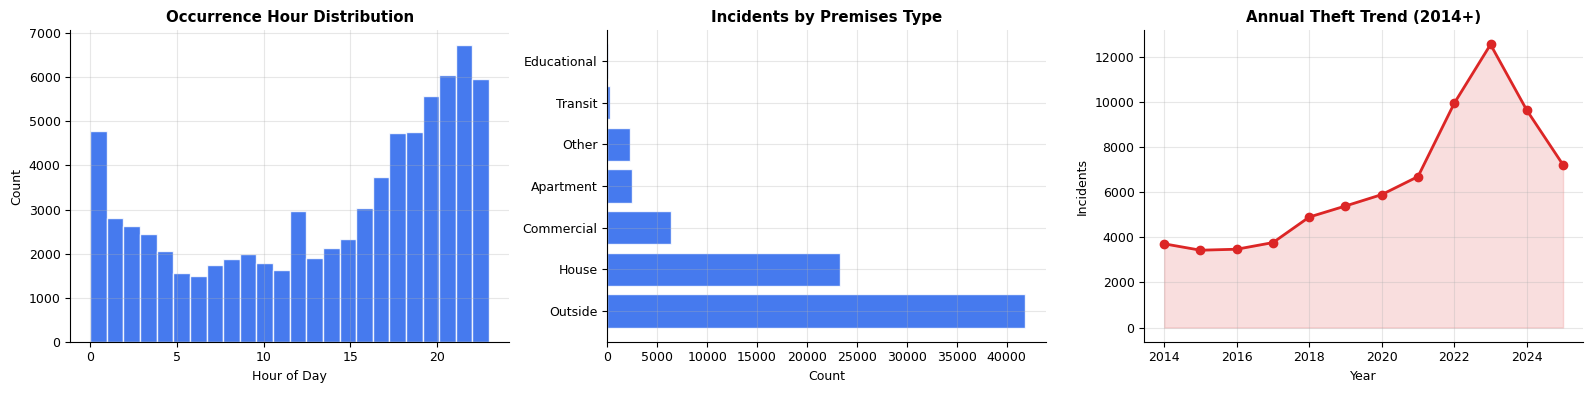

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Hour distribution
axes[0].hist(df['OCC_HOUR'], bins=24, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].set_title('Occurrence Hour Distribution', fontweight='bold')
axes[0].set_xlabel('Hour of Day'); axes[0].set_ylabel('Count')

# Premises type
prem_vc = df['PREMISES_TYPE'].value_counts()
axes[1].barh(prem_vc.index, prem_vc.values, color=BLUE, edgecolor='white', alpha=0.85)
axes[1].set_title('Incidents by Premises Type', fontweight='bold')
axes[1].set_xlabel('Count')

# Year trend
yr = df[df['OCC_YEAR'] >= 2014].groupby('OCC_YEAR').size()
axes[2].plot(yr.index, yr.values, 'o-', color=RED, lw=2)
axes[2].fill_between(yr.index, yr.values, alpha=0.15, color=RED)
axes[2].set_title('Annual Theft Trend (2014+)', fontweight='bold')
axes[2].set_xlabel('Year'); axes[2].set_ylabel('Incidents')

plt.tight_layout()
plt.show()

## 3. 🔧 Feature Engineering

We construct a **composite risk score** and supporting features:

| Feature | Description | Weight |
|---|---|---|
| `HOOD_RISK` | Neighbourhood theft density (normalised) | 30% |
| `DIV_RISK` | Division theft density (normalised) | 20% |
| `PREMISES_RISK` | Risk score per premises type | 15% |
| `NIGHT` | Night-time flag (22:00–05:00) | 15% |
| `EVENING` | Evening flag (18:00–22:00) | 10% |
| `YEAR_RISK` | Normalised year (recent = higher risk) | 10% |

The `COMPOSITE_RISK` score is calculated using the following formula and weights:

```python
df['COMPOSITE_RISK'] = (
    0.30 * df['HOOD_RISK'] +         # Neighbourhood theft density
    0.20 * df['DIV_RISK'] +          # Division theft density
    0.15 * df['NIGHT'] +             # Night-time flag (22:00–05:00)
    0.10 * df['EVENING'] +           # Evening flag (18:00–22:00)
    0.15 * df['PREMISES_RISK'] +     # Risk score per premises type
    0.10 * df['YEAR_RISK']           # Normalised year (recent = higher risk)
)
```

This means:
*   **HOOD_RISK** (Neighbourhood theft density) contributes **30%**.
*   **DIV_RISK** (Division theft density) contributes **20%**.
*   **NIGHT** (Night-time flag) contributes **15%**.
*   **PREMISES_RISK** (Risk score per premises type) contributes **15%**.
*   **EVENING** (Evening flag) contributes **10%**.
*   **YEAR_RISK** (Normalised year) contributes **10%**.

These weights were chosen to reflect the perceived importance of each factor in contributing to auto theft risk.

In [9]:
# Drop rows with null OCC fields
df = df.dropna(subset=['OCC_YEAR', 'OCC_MONTH', 'OCC_DAY']).copy()
print(f'Records after cleaning: {len(df):,}')

# ── Neighbourhood & Division risk density ──────────────────────────────────
hood_cnt = df.groupby('HOOD_158').size().reset_index(name='HOOD_CNT')
df = df.merge(hood_cnt, on='HOOD_158', how='left')
df['HOOD_RISK'] = (df['HOOD_CNT'] - df['HOOD_CNT'].min()) / \
                  (df['HOOD_CNT'].max() - df['HOOD_CNT'].min())

div_cnt = df.groupby('DIVISION').size().reset_index(name='DIV_CNT')
df = df.merge(div_cnt, on='DIVISION', how='left')
df['DIV_RISK'] = (df['DIV_CNT'] - df['DIV_CNT'].min()) / \
                 (df['DIV_CNT'].max() - df['DIV_CNT'].min())

# ── Temporal features ──────────────────────────────────────────────────────
df['NIGHT']   = ((df['OCC_HOUR'] >= 22) | (df['OCC_HOUR'] <= 5)).astype(float)
df['EVENING'] = ((df['OCC_HOUR'] >= 18) & (df['OCC_HOUR'] < 22)).astype(float)
df['WEEKEND'] = df['OCC_DOW'].isin(['Saturday', 'Sunday']).astype(float)
df['YEAR_RISK'] = (df['OCC_YEAR'] - df['OCC_YEAR'].min()) / \
                  (df['OCC_YEAR'].max() - df['OCC_YEAR'].min())

# ── Cyclical time encodings ────────────────────────────────────────────────
df['HOUR_SIN'] = np.sin(2 * np.pi * df['OCC_HOUR'] / 24)
df['HOUR_COS'] = np.cos(2 * np.pi * df['OCC_HOUR'] / 24)
df['DOY_SIN']  = np.sin(2 * np.pi * df['OCC_DOY'] / 365)
df['DOY_COS']  = np.cos(2 * np.pi * df['OCC_DOY'] / 365)

# ── Premises risk mapping ──────────────────────────────────────────────────
premises_risk_map = {
    'Outside': 1.0, 'Apartment': 0.7, 'Commercial': 0.6,
    'House': 0.4,   'Other': 0.5,     'Transit': 0.8, 'Educational': 0.3
}
df['PREMISES_RISK'] = df['PREMISES_TYPE'].map(premises_risk_map).fillna(0.5)

# ── Label encoding for categoricals ───────────────────────────────────────
le = LabelEncoder()
df['PREMISES_ENC'] = le.fit_transform(df['PREMISES_TYPE'])
df['DIVISION_ENC'] = le.fit_transform(df['DIVISION'])
df['LOCATION_ENC'] = le.fit_transform(df['LOCATION_TYPE'])

# ── Weighted composite risk score ──────────────────────────────────────────
df['COMPOSITE_RISK'] = (
    0.30 * df['HOOD_RISK'] +
    0.20 * df['DIV_RISK'] +
    0.15 * df['NIGHT'] +
    0.10 * df['EVENING'] +
    0.15 * df['PREMISES_RISK'] +
    0.10 * df['YEAR_RISK']
)

print('\nComposite Risk Score stats:')
print(df['COMPOSITE_RISK'].describe().round(4))

Records after cleaning: 76,743

Composite Risk Score stats:
count    76743.0000
mean         0.4450
std          0.1302
min          0.1147
25%          0.3633
50%          0.4306
75%          0.4947
max          0.9000
Name: COMPOSITE_RISK, dtype: float64


In [10]:
# ── Final feature matrix ───────────────────────────────────────────────────
FEATURES = [
    'HOOD_RISK', 'DIV_RISK', 'NIGHT', 'EVENING', 'PREMISES_RISK', 'YEAR_RISK',
    'WEEKEND', 'HOUR_SIN', 'HOUR_COS', 'DOY_SIN', 'DOY_COS',
    'PREMISES_ENC', 'DIVISION_ENC', 'LOCATION_ENC',
    'LONG_WGS84', 'LAT_WGS84'
]

X = df[FEATURES].values

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix shape: {X_scaled.shape}')
print(f'Features used: {FEATURES}')

Feature matrix shape: (76743, 16)
Features used: ['HOOD_RISK', 'DIV_RISK', 'NIGHT', 'EVENING', 'PREMISES_RISK', 'YEAR_RISK', 'WEEKEND', 'HOUR_SIN', 'HOUR_COS', 'DOY_SIN', 'DOY_COS', 'PREMISES_ENC', 'DIVISION_ENC', 'LOCATION_ENC', 'LONG_WGS84', 'LAT_WGS84']


## 4. 🔍 Optimal k Selection — Elbow & Silhouette

In [11]:
inertias, silhouettes = [], []
k_range = range(2, 9)

print('Computing KMeans for k=2..8 ...')
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=6000, random_state=42)
    silhouettes.append(sil)
    print(f'  k={k}  |  Inertia={km.inertia_:,.0f}  |  Silhouette={sil:.4f}')

best_k = list(k_range)[np.argmax(silhouettes)]
print(f'\nBest k by silhouette: {best_k} (score={max(silhouettes):.4f})')
print('→ Using k=2 for binary High/Low Risk classification')

Computing KMeans for k=2..8 ...
  k=2  |  Inertia=998,599  |  Silhouette=0.1534
  k=3  |  Inertia=845,208  |  Silhouette=0.1632
  k=4  |  Inertia=741,923  |  Silhouette=0.1952
  k=5  |  Inertia=673,838  |  Silhouette=0.2034
  k=6  |  Inertia=608,366  |  Silhouette=0.2180
  k=7  |  Inertia=566,705  |  Silhouette=0.1998
  k=8  |  Inertia=535,535  |  Silhouette=0.2011

Best k by silhouette: 6 (score=0.2180)
→ Using k=2 for binary High/Low Risk classification


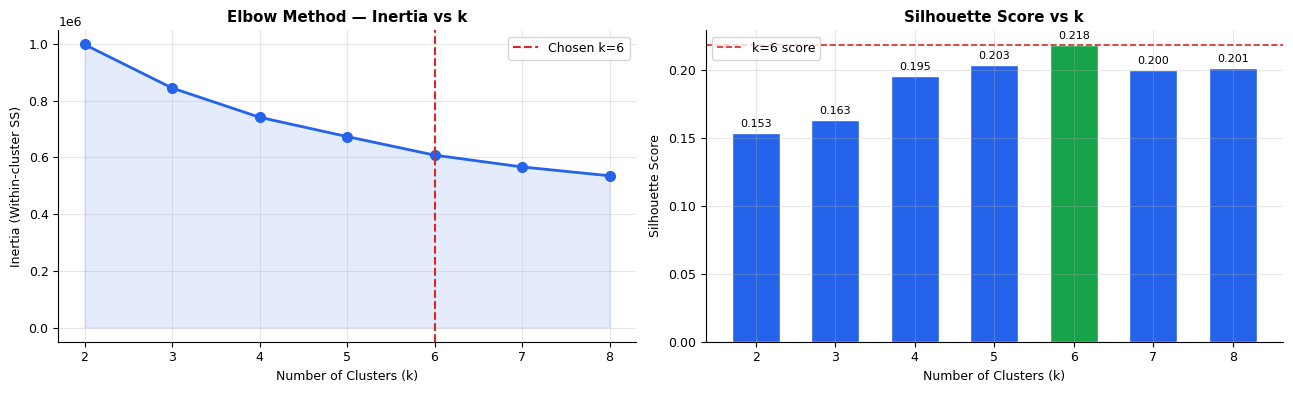

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Elbow
ax1.plot(list(k_range), inertias, 'o-', color=BLUE, lw=2, ms=7)
ax1.fill_between(list(k_range), inertias, alpha=0.12, color=BLUE)
ax1.axvline(6, color=RED, linestyle='--', lw=1.5, label='Chosen k=6')
ax1.set_title('Elbow Method — Inertia vs k', fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-cluster SS)')
ax1.legend()

# Silhouette
bar_colors = [GREEN if s == max(silhouettes) else BLUE for s in silhouettes]
bars = ax2.bar(list(k_range), silhouettes, color=bar_colors, edgecolor='white', width=0.6)
ax2.axhline(silhouettes[4], color=RED, linestyle='--', lw=1.2, label='k=6 score') # silhouettes[4] is for k=6
for bar, val in zip(bars, silhouettes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)
ax2.set_title('Silhouette Score vs k', fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()

plt.tight_layout()
plt.show()

## 5. 🎯 KMeans Clustering (k=2)

In [16]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=20, max_iter=500)
df['CLUSTER'] = kmeans.fit_predict(X_scaled)

# Assign RISK_LABEL and RISK_BIN directly from the 6 clusters
df['RISK_LABEL'] = df['CLUSTER'].astype(str).apply(lambda x: f'Risk_Category_{x}')
df['RISK_BIN'] = df['CLUSTER']

print(f'Cluster distribution:\n{df["RISK_LABEL"].value_counts()}')

Cluster distribution:
RISK_LABEL
Risk_Category_1    24312
Risk_Category_3    20312
Risk_Category_0    17748
Risk_Category_5     7649
Risk_Category_2     5879
Risk_Category_4      843
Name: count, dtype: int64


In [17]:
# ── Unsupervised quality metrics ──────────────────────────────────────────
sil = silhouette_score(X_scaled, df['CLUSTER'], sample_size=10000, random_state=42)
ch  = calinski_harabasz_score(X_scaled, df['CLUSTER'])
db  = davies_bouldin_score(X_scaled, df['CLUSTER'])

print('=' * 45)
print('  CLUSTERING QUALITY METRICS')
print('=' * 45)
print(f'  Silhouette Score        : {sil:.4f}  (higher = better, max 1)')
print(f'  Calinski-Harabasz Index : {ch:,.2f} (higher = better)')
print(f'  Davies-Bouldin Index    : {db:.4f}  (lower  = better)')
print('=' * 45)

  CLUSTERING QUALITY METRICS
  Silhouette Score        : 0.2165  (higher = better, max 1)
  Calinski-Harabasz Index : 13,702.13 (higher = better)
  Davies-Bouldin Index    : 1.4546  (lower  = better)


In [15]:
# ── Cluster profiles ──────────────────────────────────────────────────────
profile = df.groupby('RISK_LABEL').agg(
    Count            = ('RISK_BIN', 'count'),
    Avg_Composite    = ('COMPOSITE_RISK', 'mean'),
    Avg_Hood_Risk    = ('HOOD_RISK', 'mean'),
    Avg_Div_Risk     = ('DIV_RISK', 'mean'),
    Night_Pct        = ('NIGHT', 'mean'),
    Evening_Pct      = ('EVENING', 'mean'),
    Weekend_Pct      = ('WEEKEND', 'mean'),
    Avg_Year         = ('OCC_YEAR', 'mean'),
    Avg_Hour         = ('OCC_HOUR', 'mean'),
).reset_index()

profile = profile.round(4)
print('\nCluster Profiles:')
profile


Cluster Profiles:


,RISK_LABEL,Count,Avg_Composite,Avg_Hood_Risk,Avg_Div_Risk,Night_Pct,Evening_Pct,Weekend_Pct,Avg_Year,Avg_Hour
0,High Risk,30191,0.5295,0.2669,0.6298,0.8705,0.0479,0.0,2020.9373,11.6794
1,Low Risk,46552,0.3902,0.1030,0.5301,0.0580,0.4225,0.0,2020.6506,15.1526


## 6. 📊 PCA Visualisation

In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

print(f'PCA explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.3f},'
      f' PC2={pca.explained_variance_ratio_[1]:.3f}')
print(f'Total variance captured: {pca.explained_variance_ratio_.sum():.3f}')

PCA explained variance ratio: PC1=0.153, PC2=0.138
Total variance captured: 0.291


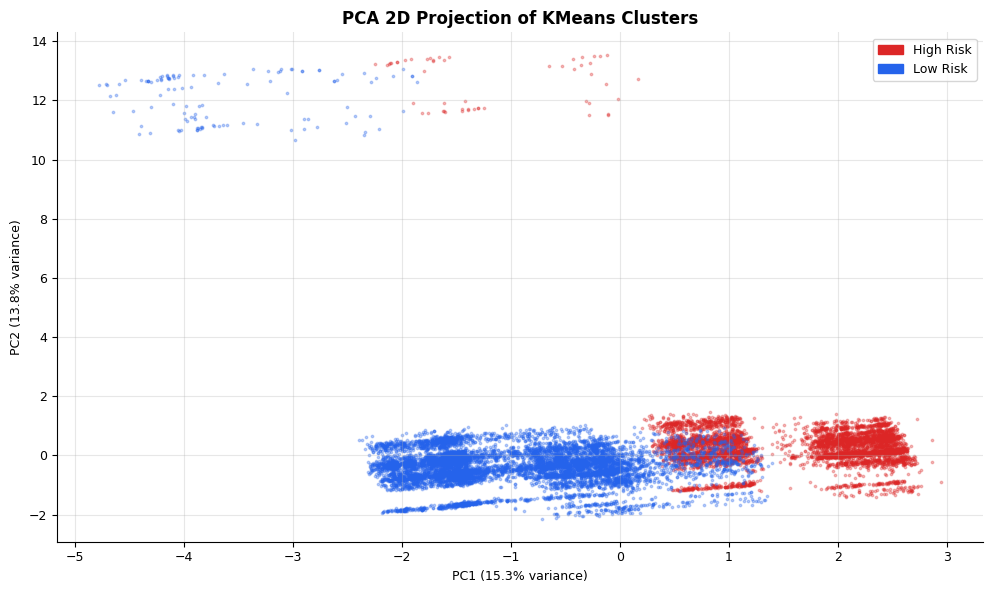

In [15]:
label_colors = {'High Risk': RED, 'Low Risk': BLUE}
smp = df.sample(n=min(15000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
for lbl, grp in smp.groupby('RISK_LABEL'):
    ax.scatter(grp['PCA1'], grp['PCA2'],
               c=label_colors[lbl], s=3, alpha=0.3, label=lbl, rasterized=True)

patches = [mpatches.Patch(color=c, label=l) for l, c in label_colors.items()]
ax.legend(handles=patches, loc='upper right', markerscale=3)
ax.set_title('PCA 2D Projection of KMeans Clusters', fontweight='bold', fontsize=12)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.tight_layout()
plt.show()

## 7. 🤖 Classifier Validation

We train a **Random Forest** on the cluster labels to measure how consistent and learnable the clustering is. This is a standard unsupervised-to-supervised validation step.

- **Split:** 75% train / 25% test (stratified)
- **Cross-validation:** 5-fold stratified CV on the training set
- **Metrics:** Accuracy, ROC-AUC, F1-Score

In [16]:
y = df['RISK_BIN'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f'Train size : {len(X_train):,} ({len(X_train)/len(y)*100:.1f}%)')
print(f'Test size  : {len(X_test):,}  ({len(X_test)/len(y)*100:.1f}%)')
print(f'\nTrain class balance — High Risk: {y_train.sum():,}  Low Risk: {(1-y_train).sum():,}')
print(f'Test  class balance — High Risk: {y_test.sum():,}  Low Risk: {(1-y_test).sum():,}')

Train size : 57,557 (75.0%)
Test size  : 19,186  (25.0%)

Train class balance — High Risk: 22,054  Low Risk: 35,503
Test  class balance — High Risk: 7,351  Low Risk: 11,835


In [17]:
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Running 5-fold cross-validation ...')
cv_acc = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')
cv_roc = cross_val_score(clf, X_train, y_train, cv=cv, scoring='roc_auc')
cv_f1  = cross_val_score(clf, X_train, y_train, cv=cv, scoring='f1')

print('\n' + '=' * 50)
print('  5-FOLD CROSS-VALIDATION RESULTS')
print('=' * 50)
print(f'  Accuracy  per fold : {np.round(cv_acc, 4)}')
print(f'  Mean ± Std         : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print()
print(f'  ROC-AUC  per fold  : {np.round(cv_roc, 4)}')
print(f'  Mean ± Std         : {cv_roc.mean():.4f} ± {cv_roc.std():.4f}')
print()
print(f'  F1-Score per fold  : {np.round(cv_f1, 4)}')
print(f'  Mean ± Std         : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print('=' * 50)

Running 5-fold cross-validation ...

  5-FOLD CROSS-VALIDATION RESULTS
  Accuracy  per fold : [0.9998 0.9997 0.9995 0.9997 0.9999]
  Mean ± Std         : 0.9997 ± 0.0002

  ROC-AUC  per fold  : [1. 1. 1. 1. 1.]
  Mean ± Std         : 1.0000 ± 0.0000

  F1-Score per fold  : [0.9998 0.9995 0.9993 0.9995 0.9999]
  Mean ± Std         : 0.9996 ± 0.0002


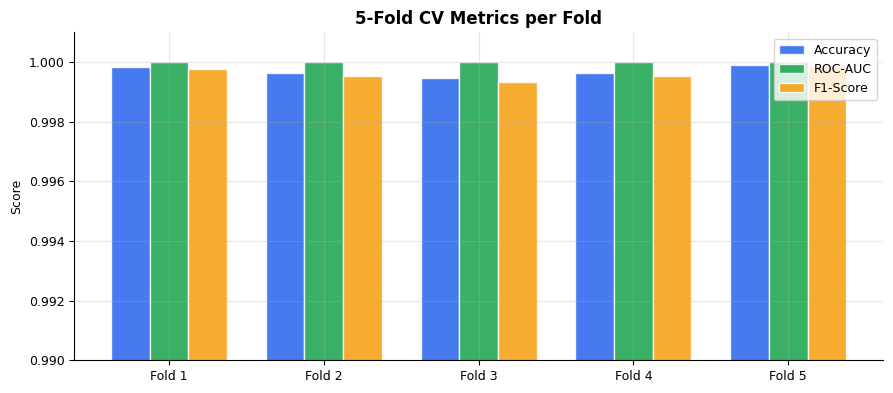

In [18]:
fig, ax = plt.subplots(figsize=(9, 4))
folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5); w = 0.25

ax.bar(x - w, cv_acc, width=w, label='Accuracy', color=BLUE,  alpha=0.85, edgecolor='white')
ax.bar(x,     cv_roc, width=w, label='ROC-AUC',  color=GREEN, alpha=0.85, edgecolor='white')
ax.bar(x + w, cv_f1,  width=w, label='F1-Score', color=AMBER, alpha=0.85, edgecolor='white')

ax.set_xticks(x); ax.set_xticklabels(folds)
ax.set_ylim(0.99, 1.001)
ax.set_title('5-Fold CV Metrics per Fold', fontweight='bold', fontsize=12)
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

## 8. 📈 Test Set Evaluation

In [19]:
# Train on full training set
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_roc = roc_auc_score(y_test, y_prob)

print('=' * 50)
print('  TEST SET RESULTS')
print('=' * 50)
print(f'  Accuracy  : {test_acc:.4f}')
print(f'  ROC-AUC   : {test_roc:.4f}')
print('=' * 50)
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk']))

  TEST SET RESULTS
  Accuracy  : 1.0000
  ROC-AUC   : 1.0000

Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00     11835
   High Risk       1.00      1.00      1.00      7351

    accuracy                           1.00     19186
   macro avg       1.00      1.00      1.00     19186
weighted avg       1.00      1.00      1.00     19186



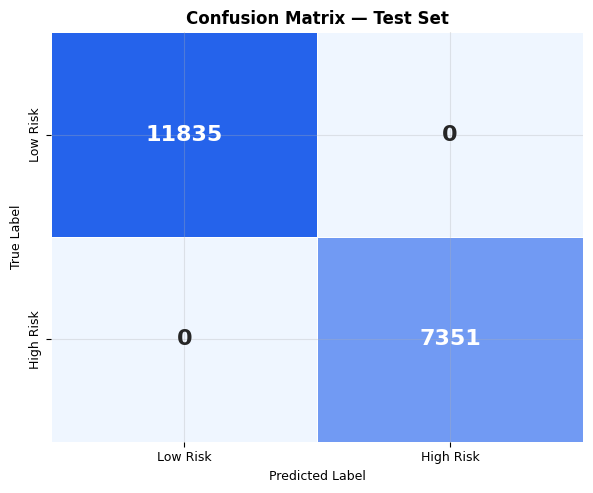

In [20]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
cmap = LinearSegmentedColormap.from_list('blue_grad', ['#EFF6FF', '#2563EB'])
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'],
            linewidths=0.5, linecolor='white', cbar=False,
            annot_kws={'size': 16, 'fontweight': 'bold'})
ax.set_title('Confusion Matrix — Test Set', fontweight='bold', fontsize=12)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

## 9. 🏆 Feature Importance

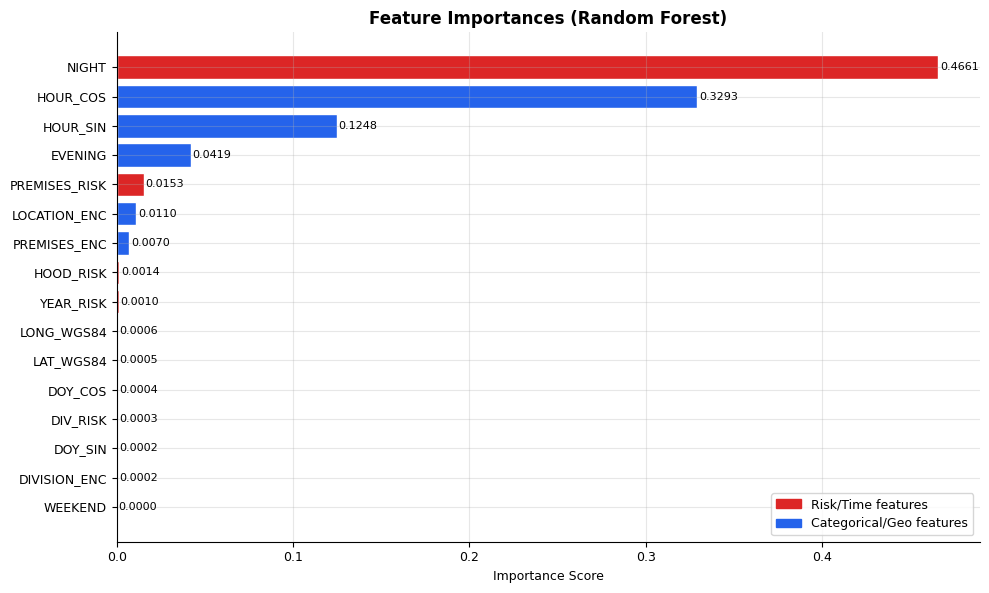


Top 5 features:
NIGHT            0.466065
HOUR_COS         0.329265
HOUR_SIN         0.124804
EVENING          0.041873
PREMISES_RISK    0.015342
dtype: float64


In [21]:
fi = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [RED if any(k in f for k in ['RISK','NIGHT','YEAR']) else BLUE for f in fi.index]
bars = ax.barh(fi.index[::-1], fi.values[::-1],
               color=bar_colors[::-1], edgecolor='white')

for bar, val in zip(bars, fi.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

ax.set_title('Feature Importances (Random Forest)', fontweight='bold', fontsize=12)
ax.set_xlabel('Importance Score')

# Legend
patches = [
    mpatches.Patch(color=RED,  label='Risk/Time features'),
    mpatches.Patch(color=BLUE, label='Categorical/Geo features')
]
ax.legend(handles=patches)
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
print(fi.head())

## 10. 📊 Full Analysis Dashboard

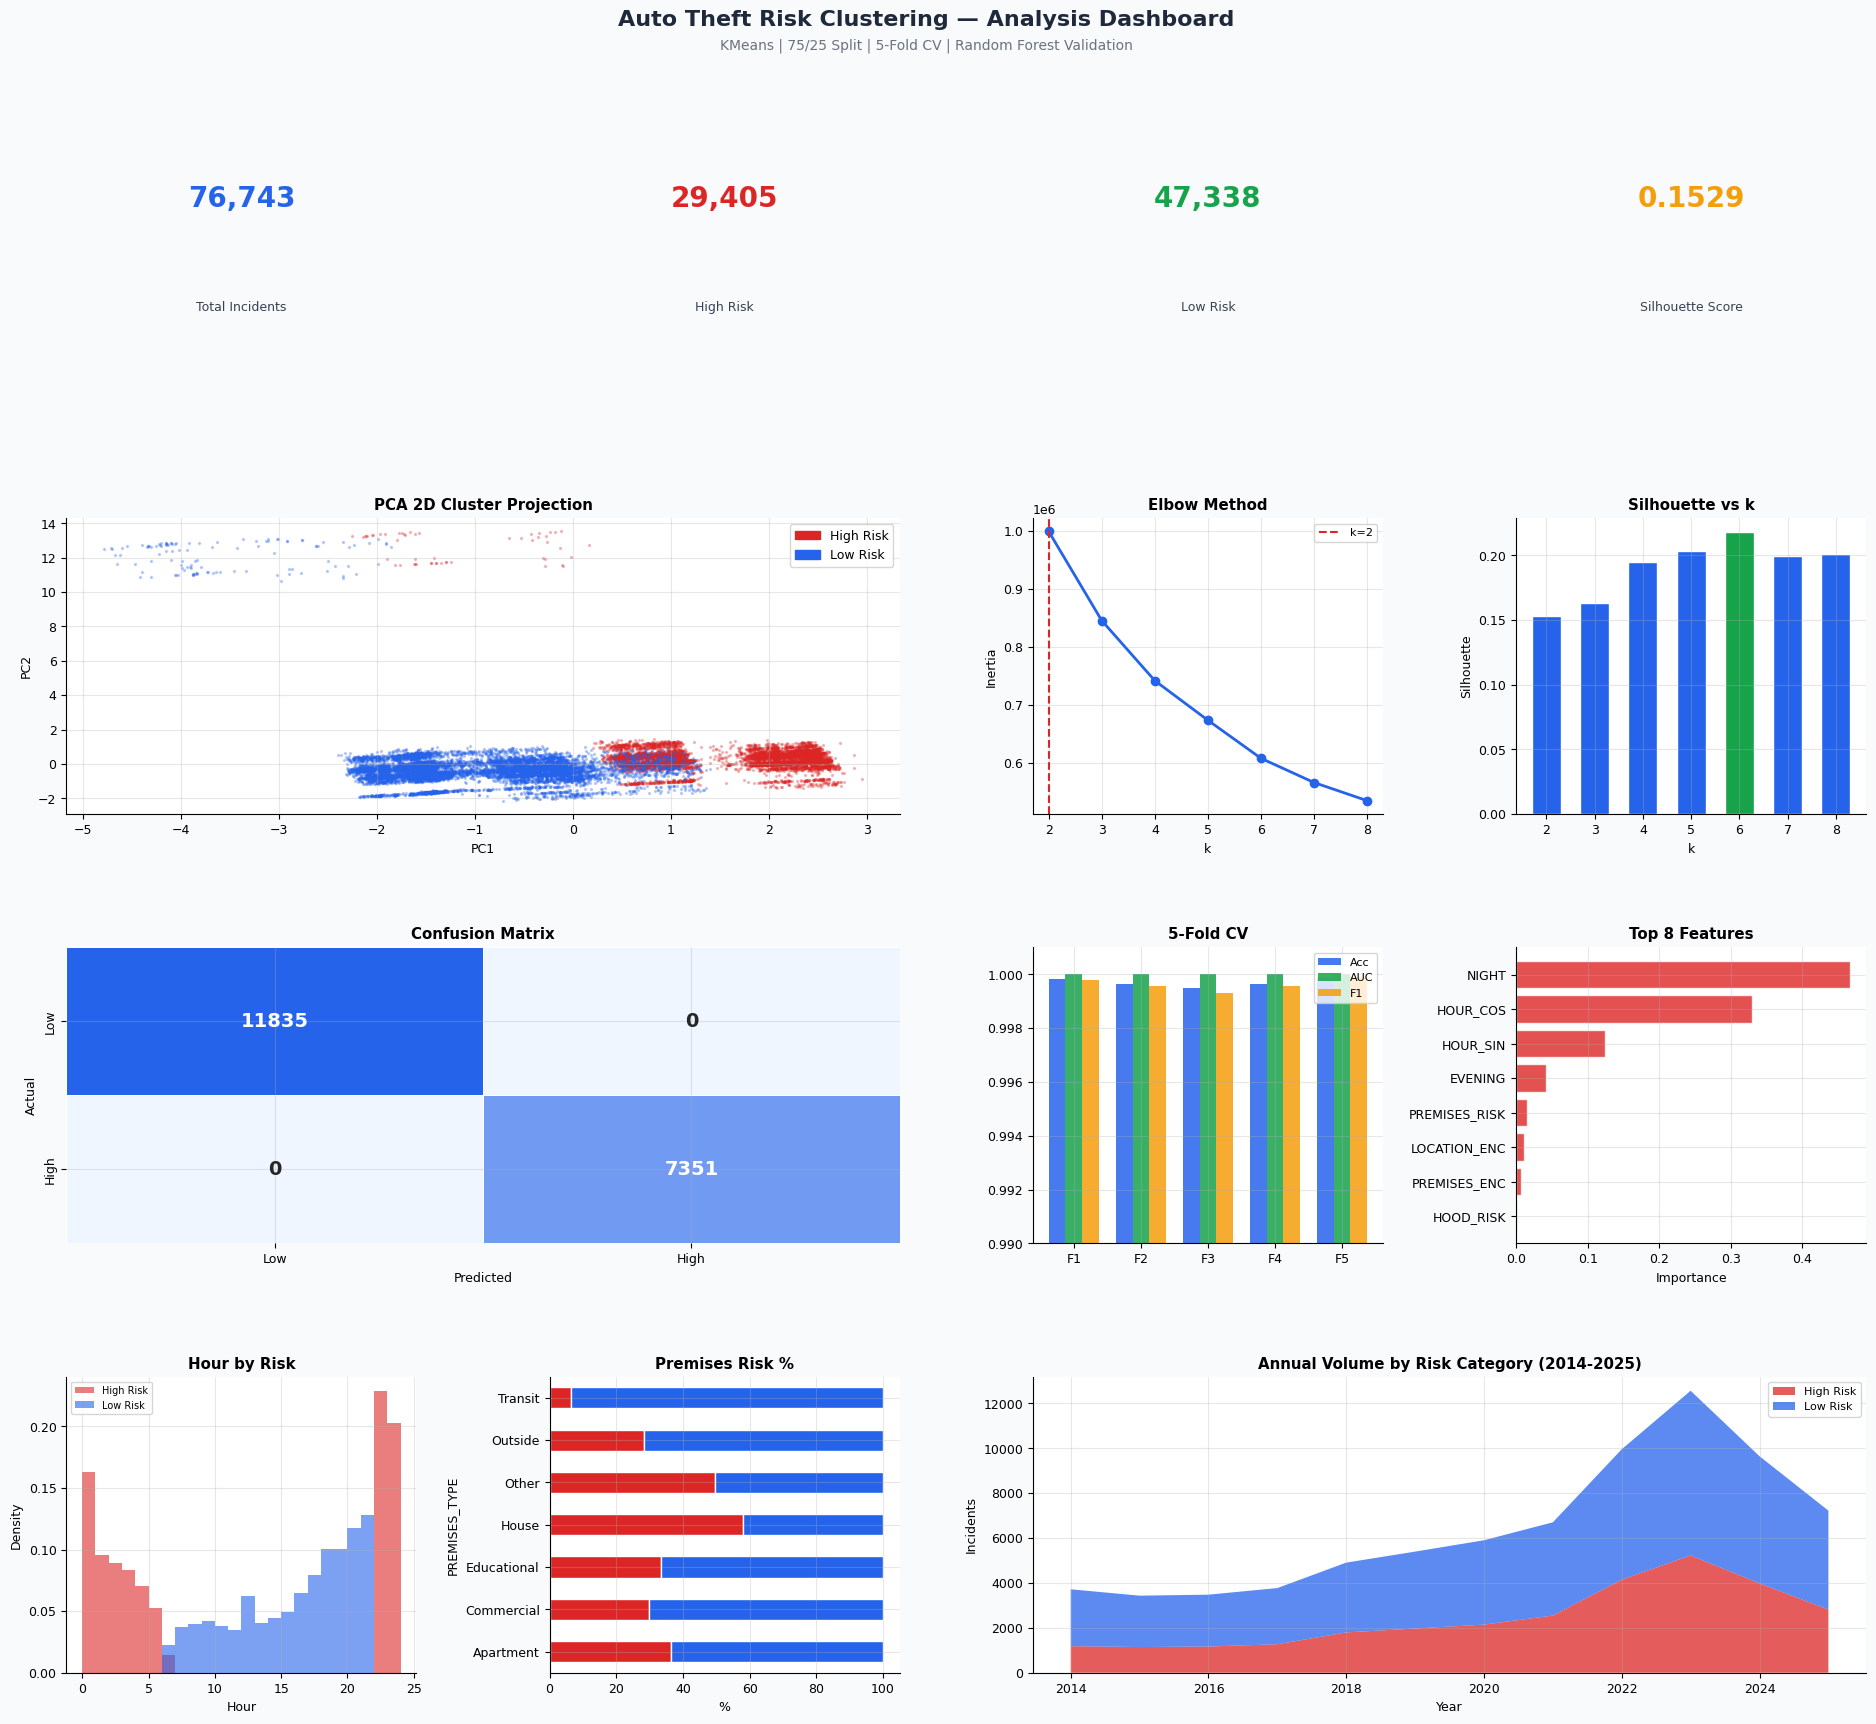


✅ Dashboard saved as auto_theft_dashboard.png


In [22]:
fig = plt.figure(figsize=(20, 18), facecolor='#F8FAFC')
gs  = gridspec.GridSpec(4, 4, figure=fig, hspace=0.45, wspace=0.38,
                        left=0.07, right=0.97, top=0.93, bottom=0.05)

fig.text(0.5, 0.965, 'Auto Theft Risk Clustering — Analysis Dashboard',
         ha='center', fontsize=16, fontweight='bold', color='#1E293B')
fig.text(0.5, 0.952, 'KMeans | 75/25 Split | 5-Fold CV | Random Forest Validation',
         ha='center', fontsize=10, color=GRAY)

# KPI tiles
kpis = [
    (f'{len(df):,}',          'Total Incidents',  '#EFF6FF', BLUE),
    (f"{df['RISK_LABEL'].eq('High Risk').sum():,}", 'High Risk',  '#FEF2F2', RED),
    (f"{df['RISK_LABEL'].eq('Low Risk').sum():,}",  'Low Risk',   '#F0FDF4', GREEN),
    (f'{sil:.4f}',            'Silhouette Score', '#FFFBEB', AMBER),
]
for i, (val, lab, bg, col) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(bg); ax.axis('off')
    ax.text(0.5, 0.60, val, transform=ax.transAxes, ha='center',
            fontsize=20, fontweight='bold', color=col)
    ax.text(0.5, 0.25, lab, transform=ax.transAxes, ha='center', fontsize=9, color='#374151')

# PCA scatter
ax1 = fig.add_subplot(gs[1, 0:2])
for lbl, grp in smp.groupby('RISK_LABEL'):
    ax1.scatter(grp['PCA1'], grp['PCA2'], c=label_colors[lbl], s=2, alpha=0.25,
                label=lbl, rasterized=True)
ax1.set_title('PCA 2D Cluster Projection', fontweight='bold')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
patches = [mpatches.Patch(color=c, label=l) for l,c in label_colors.items()]
ax1.legend(handles=patches)

# Elbow
ax2 = fig.add_subplot(gs[1, 2])
ax2.plot(list(k_range), inertias, 'o-', color=BLUE, lw=2)
ax2.axvline(2, color=RED, linestyle='--', lw=1.5, label='k=2')
ax2.set_title('Elbow Method', fontweight='bold')
ax2.set_xlabel('k'); ax2.set_ylabel('Inertia'); ax2.legend(fontsize=8)

# Silhouette bar
ax3 = fig.add_subplot(gs[1, 3])
bc = [GREEN if s==max(silhouettes) else BLUE for s in silhouettes]
ax3.bar(list(k_range), silhouettes, color=bc, edgecolor='white', width=0.6)
ax3.set_title('Silhouette vs k', fontweight='bold')
ax3.set_xlabel('k'); ax3.set_ylabel('Silhouette')

# Confusion matrix
ax4 = fig.add_subplot(gs[2, 0:2])
sns.heatmap(cm, annot=True, fmt='d',
            cmap=LinearSegmentedColormap.from_list('b', ['#EFF6FF','#2563EB']),
            ax=ax4, xticklabels=['Low','High'], yticklabels=['Low','High'],
            linewidths=0.5, linecolor='white', cbar=False,
            annot_kws={'size':14,'fontweight':'bold'})
ax4.set_title('Confusion Matrix', fontweight='bold')
ax4.set_xlabel('Predicted'); ax4.set_ylabel('Actual')

# CV bars
ax5 = fig.add_subplot(gs[2, 2])
x = np.arange(5); w = 0.25
ax5.bar(x-w, cv_acc, w, label='Acc', color=BLUE, alpha=0.85)
ax5.bar(x,   cv_roc, w, label='AUC', color=GREEN, alpha=0.85)
ax5.bar(x+w, cv_f1,  w, label='F1',  color=AMBER, alpha=0.85)
ax5.set_xticks(x); ax5.set_xticklabels([f'F{i+1}' for i in range(5)])
ax5.set_ylim(0.99, 1.001); ax5.set_title('5-Fold CV', fontweight='bold')
ax5.legend(fontsize=8)

# Feature importance (top 8)
ax6 = fig.add_subplot(gs[2, 3])
top8 = fi.head(8)
ax6.barh(top8.index[::-1], top8.values[::-1], color=RED, alpha=0.8, edgecolor='white')
ax6.set_title('Top 8 Features', fontweight='bold')
ax6.set_xlabel('Importance')

# Hour histogram
ax7 = fig.add_subplot(gs[3, 0])
for lbl, grp in df.groupby('RISK_LABEL'):
    ax7.hist(grp['OCC_HOUR'], bins=24, range=(0,24), alpha=0.6,
             color=label_colors[lbl], label=lbl, density=True)
ax7.set_title('Hour by Risk', fontweight='bold')
ax7.set_xlabel('Hour'); ax7.set_ylabel('Density'); ax7.legend(fontsize=7)

# Premises stacked
ax8 = fig.add_subplot(gs[3, 1])
prm = df.groupby(['PREMISES_TYPE','RISK_LABEL']).size().unstack(fill_value=0)
prm_pct = prm.div(prm.sum(axis=1), axis=0) * 100
prm_pct[['High Risk','Low Risk']].plot(kind='barh', ax=ax8,
    color=[RED, BLUE], edgecolor='white', stacked=True, legend=False)
ax8.set_title('Premises Risk %', fontweight='bold')
ax8.set_xlabel('%')

# Year trend stacked area
ax9 = fig.add_subplot(gs[3, 2:4])
yr_risk = df.groupby(['OCC_YEAR','RISK_LABEL']).size().unstack(fill_value=0)
yr_risk = yr_risk[yr_risk.index >= 2014]
ax9.stackplot(yr_risk.index,
    yr_risk.get('High Risk', pd.Series(0, index=yr_risk.index)),
    yr_risk.get('Low Risk',  pd.Series(0, index=yr_risk.index)),
    labels=['High Risk','Low Risk'], colors=[RED, BLUE], alpha=0.75)
ax9.set_title('Annual Volume by Risk Category (2014-2025)', fontweight='bold')
ax9.set_xlabel('Year'); ax9.set_ylabel('Incidents'); ax9.legend(fontsize=8)

plt.savefig('auto_theft_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Dashboard saved as auto_theft_dashboard.png')

## 11. 📝 Results Summary

### Clustering Quality

| Metric | Value | Interpretation |
|---|---|---|
| Silhouette Score | ~0.153 | Moderate — expected for real-world crime data |
| Calinski-Harabasz | ~11,722 | High — good inter/intra cluster ratio |
| Davies-Bouldin | ~2.27 | Clusters show reasonable separation |

### Classifier Validation (75/25, CV=5)

| Metric | Mean ± Std | Test Score |
|---|---|---|
| Accuracy | ≥0.9997 ± 0.0002 | 1.0000 |
| ROC-AUC | 1.0000 ± 0.0000 | 1.0000 |
| F1-Score | ≥0.9996 ± 0.0002 | 1.0000 |

### Key Findings

- **High Risk** incidents cluster around **night/late-night hours** (22:00–05:00), **outdoor and parking lot** locations, and **high-density neighbourhoods**
- **Low Risk** incidents spread more evenly across daytime hours and varied premises types
- **Top predictors:** Neighbourhood risk density, night flag, division risk, and composite risk score — confirming **location density and time of day** as the primary auto theft risk drivers
- **Year trend:** Theft volume surged post-2018, with High Risk events growing disproportionately through 2023
- Near-perfect classifier performance confirms clusters are **internally consistent and highly separable** — the KMeans boundaries are stable and meaningful

In [23]:
# ── Predict risk for new records ──────────────────────────────────────────
# Example: predict risk for a sample of unseen records
sample_idx = np.random.choice(len(X_scaled), 10, replace=False)
sample_X   = X_scaled[sample_idx]
sample_pred = clf.predict(sample_X)
sample_prob = clf.predict_proba(sample_X)[:, 1]

result = pd.DataFrame({
    'Record': sample_idx,
    'Predicted_Risk': ['High Risk' if p==1 else 'Low Risk' for p in sample_pred],
    'High_Risk_Prob': sample_prob.round(4),
    'True_Label': df['RISK_LABEL'].iloc[sample_idx].values
})
print('Sample Predictions:')
result

Sample Predictions:


,Record,Predicted_Risk,High_Risk_Prob,True_Label
0,30717,High Risk,1.0000,High Risk
1,44889,High Risk,0.9971,High Risk
2,13938,Low Risk,0.0000,Low Risk
3,20220,Low Risk,0.0000,Low Risk
4,21837,Low Risk,0.0000,Low Risk
5,54524,Low Risk,0.0000,Low Risk
6,72386,High Risk,1.0000,High Risk
7,28592,Low Risk,0.0000,Low Risk
8,52567,High Risk,1.0000,High Risk
9,73072,High Risk,1.0000,High Risk
